# GTP3 INGENIERA DE CARACTERISTICAS Y SELECCION DE VARIABLES


### Descargo el coso

In [1]:
import gdown
file_id = '1artALqi9at8DqzTp5x8NA7P1qwJLKN24'
gdown.download(id=file_id, output='worldbank_dataset.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1artALqi9at8DqzTp5x8NA7P1qwJLKN24
To: l:\FACULTAD DE MIERDA\TERCERO\LABORTARIO DE DATOS 2\lab2 - unidad 3\worldbank_dataset.csv
100%|██████████| 2.27M/2.27M [00:00<00:00, 9.64MB/s]


'worldbank_dataset.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

### recordando lo que dijo la profe en clase sobre las variables que dan mucha informacio sobre la variable objetivo

Identifique algunas variables que si las dejamos produciria data leakage debido a que son formulas matematicas directas de la variable objetivo. Si la dejamos el modelo va a parecer perfecto pero es pq basicamente le estamos dando las respuestas.
- **gdp_current_us$**(Entiendo que es el PBI total absoluto): El PBI percapita se calcula dividiendo el PBI total por la poblacion, si le damos el total ya la estariamos dando media respuesta
- **gdp_ppp_current_international_$**(PIB ajustado por paridad de poder adquisitivo): Lo busque y es basicamente lo mismo que queremos predecir (mide la riqueza), poero ajustada a al inflacion y costo de vida, es un sinonimo literal, ARAFUE.
- **gdp_per_capita_growth_annual y gdp_growth_annual**:Son las tasas de crecimiento analues, derivan directamente de nuestra variable objetivo en el tiempo.

In [9]:
df=pd.read_csv('worldbank_dataset.csv')

#lista de variables que se van
columnas_arafue = [
    'gdp_current_us$', 
    'gdp_ppp_current_international_$', 
    'gdp_per_capita_growth_annual', 
    'gdp_growth_annual'
]

# Eliminarlas del DataFrame
df = df.drop(columns=columnas_arafue)

print(f"tamaño del dataset: {df.shape}") #habia 64 columnas originalmente
df.head()

tamaño del dataset: (3429, 60)


,country,year,heritage_score,property_rights,government_integrity,judicial_effectiveness,tax_burden,government_spending,fiscal_health,business_freedom,...,primary_energy_consumption_constant_2017_ppp_$,real_interest_rate,renewable_energy_consumption_of_total_final_energy_use,school_enrollment_primary_gross,school_enrollment_secondary_gross,school_enrollment_tertiary_gross,services_value_added_of_gdp,trade_of_gdp,unemployment_total_of_total_labor_force,unemployment_youth_ages_15-24
0,Albania,2022,66.6,55.5,35.6,49.8,89.1,72.1,70.6,70.7,...,2.06,-3.053767,NaN,96.371231,97.322472,62.647919,46.209426,84.698057,10.137,24.735
1,Albania,2021,65.2,46.1,40.6,22.8,89.0,74.6,86.6,66.1,...,2.27,2.491460,41.9,97.107498,97.665031,59.969872,45.243846,75.590322,11.474,27.244
2,Albania,2020,66.9,57.1,38.8,33.0,85.9,74.6,86.3,65.7,...,2.34,6.077295,44.4,100.020973,95.929451,61.585300,45.721359,59.520712,11.690,28.117
3,Albania,2019,66.5,54.8,40.4,30.6,86.3,73.9,80.6,69.3,...,2.45,5.222938,40.1,102.589539,99.015152,61.408508,45.453411,75.382129,11.466,26.942
4,Albania,2018,64.5,54.1,39.9,25.4,85.1,72.7,67.5,69.1,...,2.53,4.415049,37.8,104.568024,98.822388,56.080299,44.397028,75.694078,12.304,28.109


vemos un poco los datos

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3429 entries, 0 to 3428
Data columns (total 60 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   country                                                 3429 non-null   object 
 1   year                                                    3429 non-null   int64  
 2   heritage_score                                          3231 non-null   float64
 3   property_rights                                         3250 non-null   float64
 4   government_integrity                                    3262 non-null   float64
 5   judicial_effectiveness                                  860 non-null    float64
 6   tax_burden                                              3241 non-null   float64
 7   government_spending                                     3251 non-null   float64
 8   fiscal_health                         

Verificamos que no haya columnas con errores de tipeo, es decir que tengan algun texto pero deberian ser numericas.  A SIMPLE VISTA PARECERIA QUE NO IGUAL PERO SON MUCHAS COLUMNAS

In [11]:
#segun el dataset, las que deberian ser texto son 'iso_code','country','coountryiso3'
columnas_texto=['iso_code','country','countryiso3']
#hacemos un intento de filtro para ver cuales pueden tener errores de tipeo
#por ejemplo se le coloco alguna 'N/A' o "" en las numericas
columnas_sospechochas=df.select_dtypes(include=['object']).columns
columnas_con_errores= [col for col in columnas_sospechochas if col not in columnas_texto]
print(f"Columnas numericas con errores: {len(columnas_con_errores)}")



Columnas numericas con errores: 0


EL  DATASET MAS LIMPIO DE LA HISTORIA

# EJERCICIO 1: Análisis Exploratorio, Tratamiento de Faltantes y Preparación de Variables 

## 1.1 Analisis exploratorio inicial (siguiendo tal cual la consigna,no agregamos nada mas)

### Faltantes

PROPORCIÓN DE VALORES FALTANTES
TOTAL DE VARIABLES CON NULOS: 54


,Porcentaje NaN (%)
adult_literacy_rate_of_people_ages_15_and_above,80.14
fiscal_health,75.04
judicial_effectiveness,74.92
central_government_debt_of_gdp,65.88
gini_index,54.10
poverty_headcount_ratio_at_$1.90_day_of_population,54.10
poverty_headcount_ratio_at_$5.50_day_of_population,54.10
high-technology_exports_of_manufactured_exports,45.55
real_interest_rate,34.35
school_enrollment_tertiary_gross,28.99


C:\Users\lioju\AppData\Local\Temp\ipykernel_3616\2974863833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=faltantes.values[:15], y=faltantes.index[:15], palette="magma")


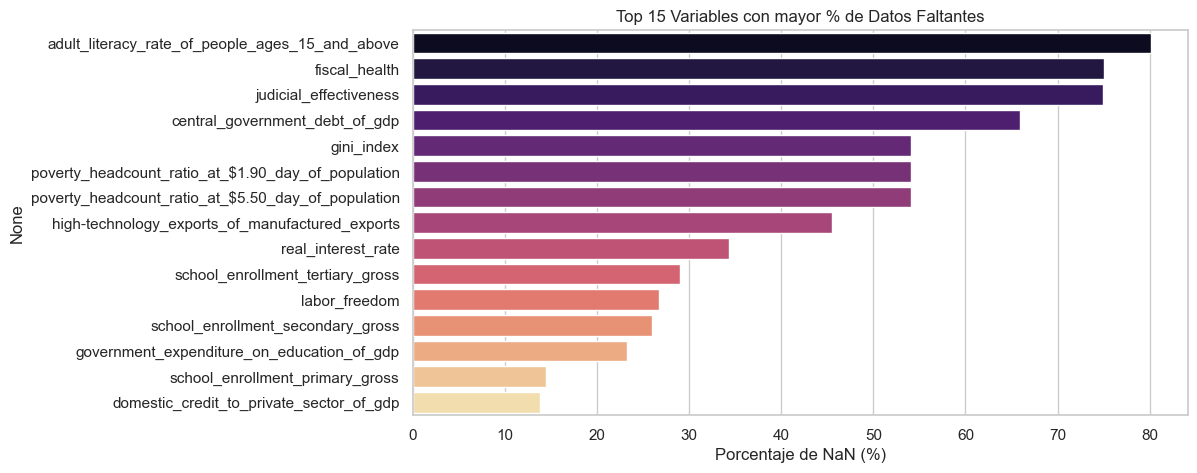

In [12]:
print("PROPORCIÓN DE VALORES FALTANTES")
faltantes = (df.isnull().sum() / len(df)) * 100
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
total_faltantes=len(faltantes)
print(F"TOTAL DE VARIABLES CON NULOS: {total_faltantes}")
display(pd.DataFrame({'Porcentaje NaN (%)': faltantes.round(2)}))

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x=faltantes.values[:15], y=faltantes.index[:15], palette="magma")
plt.title("Top 15 Variables con mayor % de Datos Faltantes")
plt.xlabel("Porcentaje de NaN (%)")
plt.show()


**CONCLUSION**:
Vemos que 'adult_literacy_rate', 'fiscal_health' y 'judicial_effectiveness' tienen 75% o mas de datos faltantes, imputar estas no tendria sentido porque estariamos "inventando" datos, las **descartamos**


Elijo algunas variables numericas que me parezcan "principales", intento justificar el por que:

- **life_expectancy_at_birth_total_years**: (Expectativa de vida): Un excelente indicador de la calidad general del sistema de salud, nutricion y saneamiento de un pais.
- **infant_mortality_rate_per_1_000_live_births**:(Mortalidad infantil): Un indicador sensible a la falta de recursos y pobreza extrema. entiendo que de aca se espera que tenga una correlacion fuertemente negativa con la riqueza del pais.
- **agriculture_value_added_of_gdp**: (Valor agregado de agricultura %): En economias en desarrollo, este sector suele representar una porcion muy alta del PIB. A mayor riqueza, este porcentaje tiende a disminuir.
- **services_value_added_of_gdp**: (Valor agregado de servicios %): Las economias mas desarrolladas se caracterizan por tener un sector de servicios dominante.
- **school_enrollment_tertiary_gross** (Matriculacion terciaria/universitaria): El nivel educativo superior es el motorcito de todo,es necesaria en un pais top (le pregunte al amigo). En nuestro pais esto debe estar re gaga
- **access_to_electricity_of_population**: (Acceso a la electricidad %): Con esto capaz filtramos a pobalciones pobres.
- **inflation_consumer_prices_annual**: (Inflación anual %): Mide la estabilidad de precios de la economia. Altos niveles de inflacion suelen asociarse a menor desarrollo o estancamiento.
- **trade_of_gdp**: (Comercio como % del PIB): Representa la suma de exportaciones e importaciones. Mide que tan abierta esta la economia de un pais hacia el mercado global. NO LO DIGO YO, LO DICE LA HISTORIA PERO ME GUARDO MIS COMENTARIOS

In [13]:
#definimos el Target y 8 variables principales A MI PARECER, SOBRE TODO EN RELAACION AL TARGET
target = 'gdp_per_capita_current_us$'

principales_vars = [
    target,
    'life_expectancy_at_birth_total_years', 
    'infant_mortality_rate_per_1_000_live_births',
    'agriculture_value_added_of_gdp',
    'services_value_added_of_gdp',
    'school_enrollment_tertiary_gross',
    'access_to_electricity_of_population',
    'inflation_consumer_prices_annual',
    'trade_of_gdp'
]


reporte = pd.DataFrame(index=principales_vars)

#rango
reporte['Mínimo'] = df[principales_vars].min()
reporte['Máximo'] = df[principales_vars].max()

#log10 del máximo absoluto, pq decia algo del orden
reporte['Orden Magnitud (10^x)'] = np.log10(df[principales_vars].abs().max()).round(1)

#Asimetria
reporte['asimetria'] = df[principales_vars].skew()

print("ANALISIS DE RANGO, MAGNITUD Y FORMA")
display(reporte.round(2))


ANALISIS DE RANGO, MAGNITUD Y FORMA


,Mínimo,Máximo,Orden Magnitud (10^x),asimetria
gdp_per_capita_current_us$,62.14,134965.82,5.1,2.31
life_expectancy_at_birth_total_years,14.66,84.56,1.9,-0.80
infant_mortality_rate_per_1_000_live_births,1.70,234.90,2.4,1.40
agriculture_value_added_of_gdp,0.03,79.04,1.9,1.42
services_value_added_of_gdp,6.45,94.15,2.0,-0.22
school_enrollment_tertiary_gross,0.26,166.67,2.2,0.44
access_to_electricity_of_population,1.30,100.00,2.0,-1.19
inflation_consumer_prices_annual,-16.86,2666.45,3.4,40.84
trade_of_gdp,0.02,437.33,2.6,2.47


- las escalas son disparejas, 'life_expectancy' se mueve en decenas, la inflacion llega a miles y el PIB per capita esta en los cientos de miles(10^5). Por lo tanto **es obligatorio aplicar tecnincas de escalado**

- En cuanto a la asimetria, praticamente ninguna tiene una dist Gaussiana. La inflacion ('inflation_consumer_prices') tiene una asimetria terrible de 40,84.... esto indica que hay valores extremos claros como paises con HIPERINFLACION. Nuestro target tambien tiene asimetria fuerte hacia la derecha con 2.31. Para estabilizar esto debemos aplicar transformaciones como Yeo-Johnson, logaritmo o box-cox


### Graficos

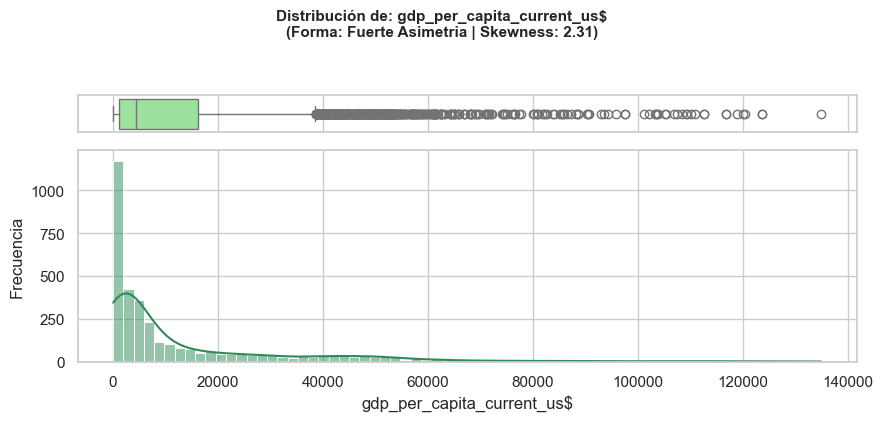

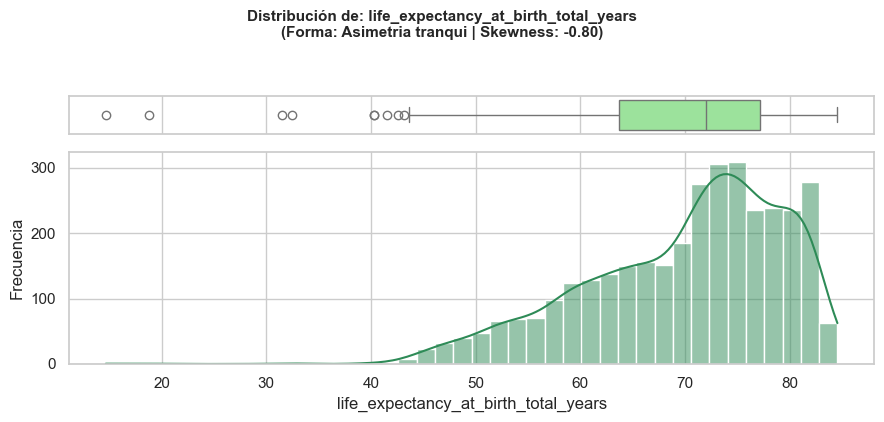

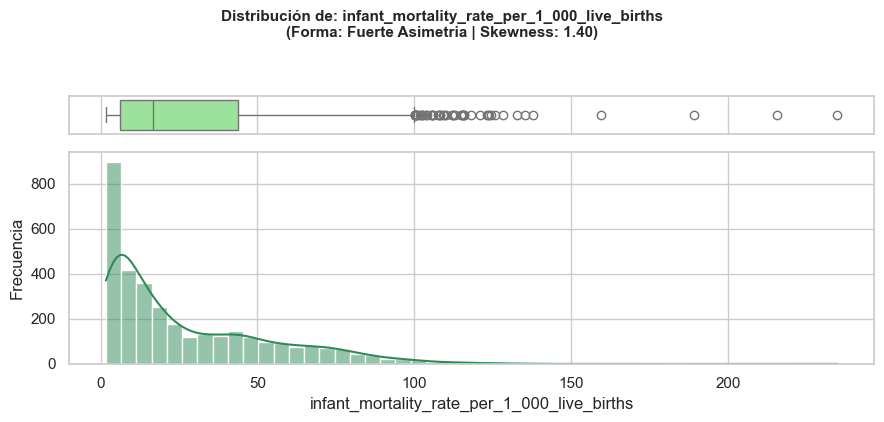

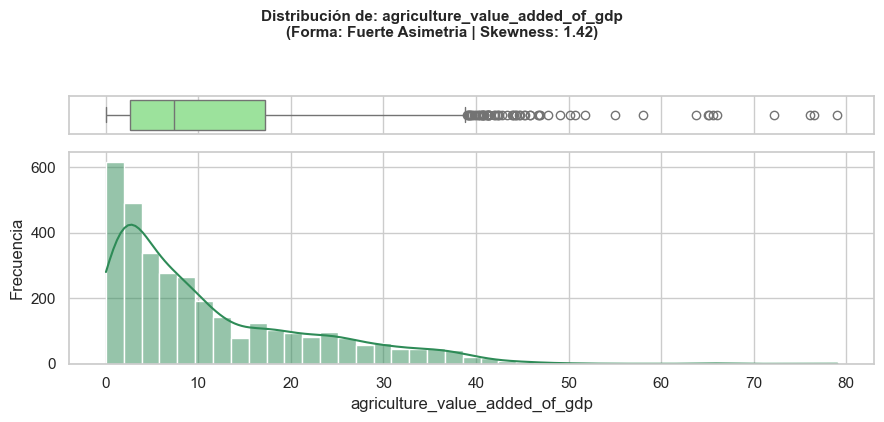

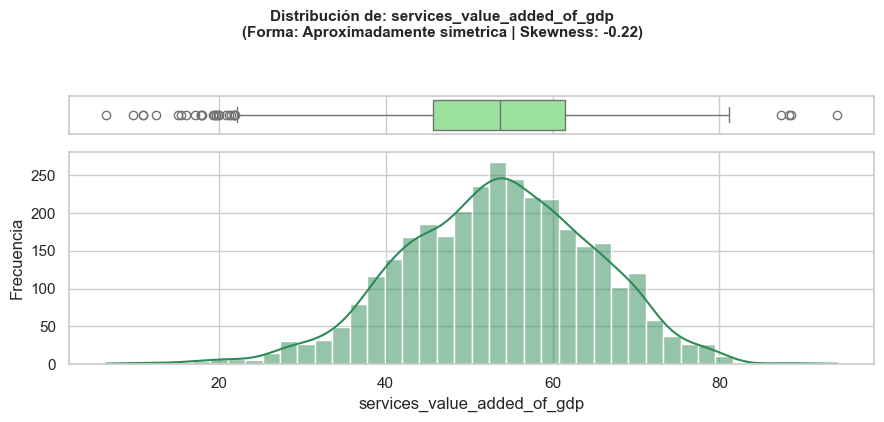

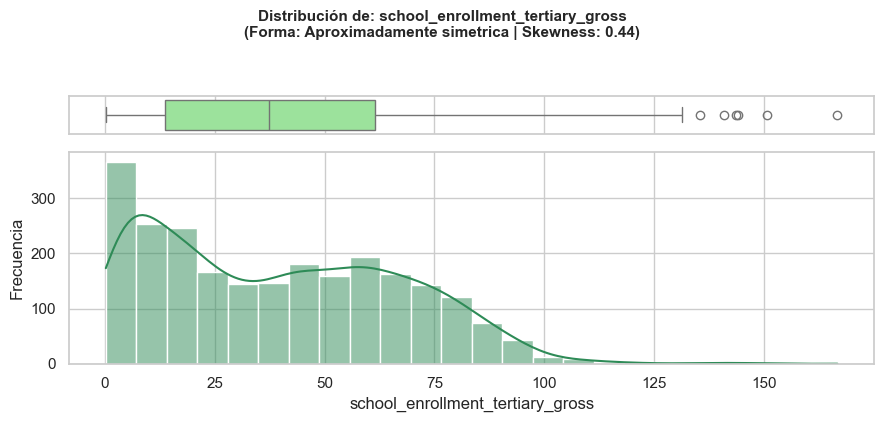

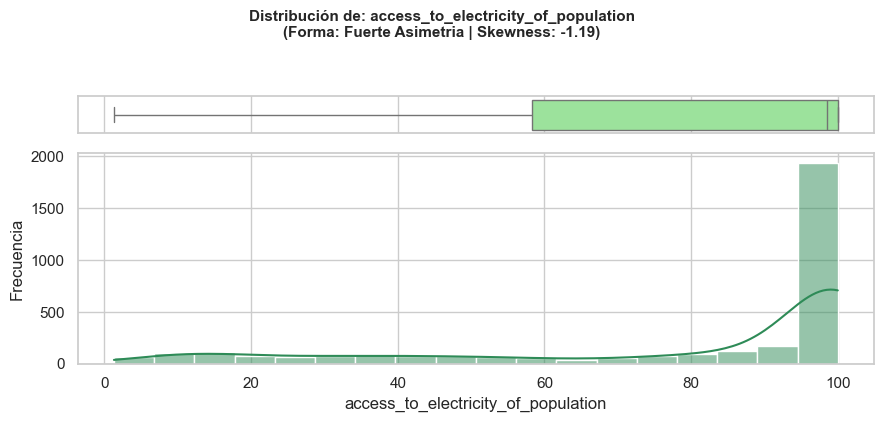

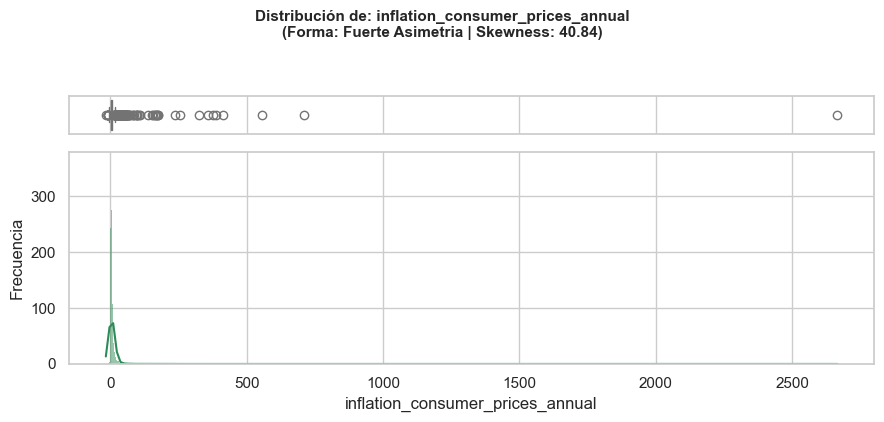

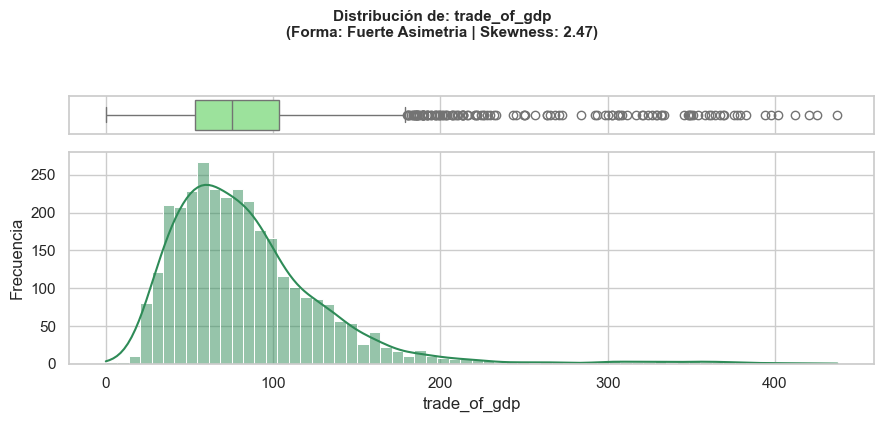

In [14]:
#histograma y Boxplot solo para nuestras variables principales
for col in principales_vars:
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)}, 
        figsize=(9, 4)
    )

    sns.boxplot(x=df[col], ax=ax_box, color="lightgreen")
    sns.histplot(data=df, x=col, ax=ax_hist, kde=True, color="seagreen")
    ax_box.set(xlabel='')
    ax_hist.set_ylabel("Frecuencia")
    #ponemos la asimetria tmb
    skew_val = df[col].skew()
    
    if abs(skew_val) > 1:
        forma = "Fuerte Asimetria"
    elif abs(skew_val) > 0.5:
        forma = "Asimetria tranqui"
    else:
        forma = "Aproximadamente simetrica"
        
    plt.suptitle(f'Distribución de: {col}\n(Forma: {forma} | Skewness: {skew_val:.2f})', 
                 y=1.05, fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


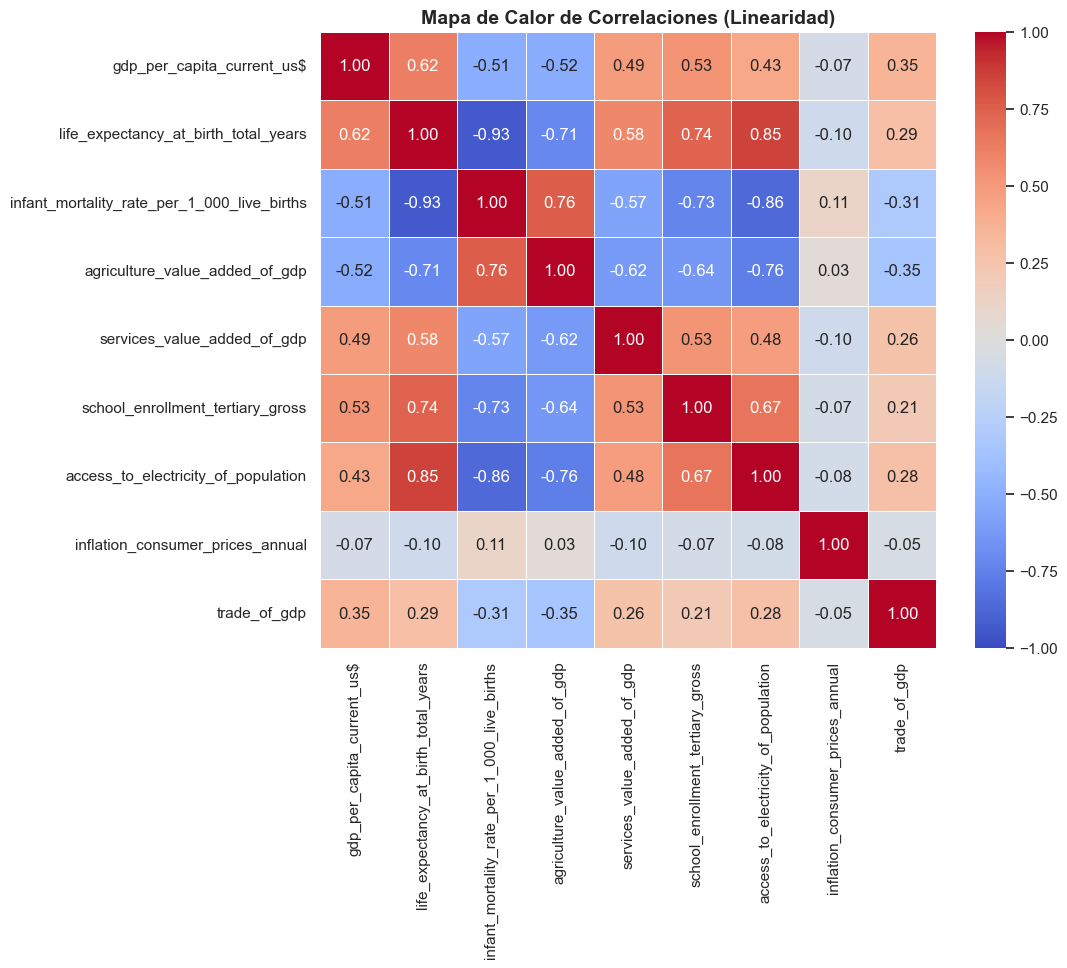

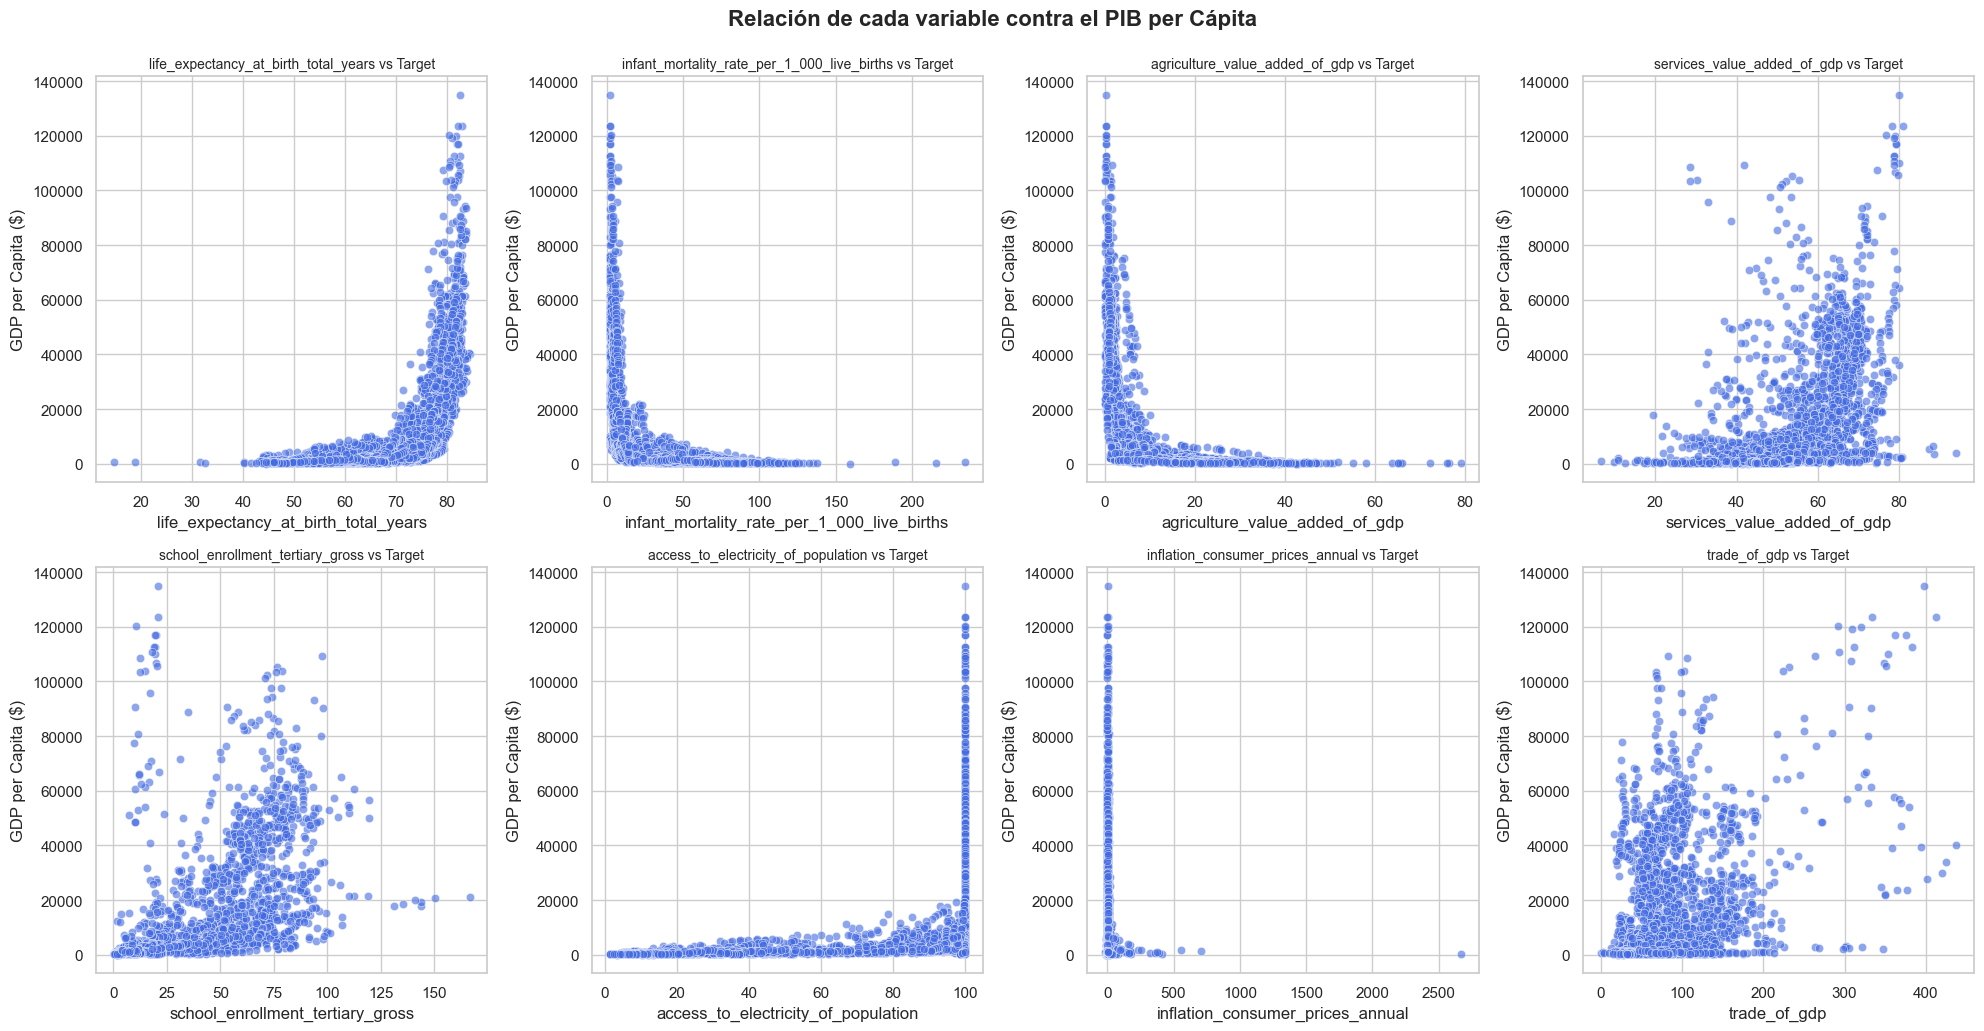

In [15]:
#Heatmap
plt.figure(figsize=(10, 8))
matriz_correlacion = df[principales_vars].corr()

sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", 
            cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Mapa de Calor de Correlaciones (Linearidad)", fontsize=14, fontweight='bold')
plt.show()

#Scatter plots contra el Target
#quitamos el target de la lista para iterar solo sobre las predictoras
variables_predictoras = [var for var in principales_vars if var != target]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_predictoras):
    sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6, color="royalblue")
    axes[i].set_title(f'{col} vs Target', fontsize=10)
    axes[i].set_ylabel("GDP per Capita ($)")
    
plt.tight_layout()
plt.suptitle("Relación de cada variable contra el PIB per Cápita", y=1.03, fontsize=16, fontweight='bold')
plt.show()


- En el heatmap vemos que el PIB tiene correlaciones positivas fuertes con la **expectativa de vida** como sospechabamos mas arriba y con la **educacion terciaria**, y tiene correlaciones negativas con la **mortalidad infantil** y la **dependencia agricola**.

- En los graficos de dispersion vemos que no tenemos relaciones lineales rectas, como que se forman muros directamente, todos los datos se agrupan. Esto indica que una regresion lineal simple nos daria muy mal para predecir el target en este estado.

# 1.2 Tratamiento de valores faltantes

Vimos antes que podiamos eliminar algunas variables.... como la consigna dice en la observacion que **no deben entenderse 
como una modificación definitiva del dataset**, por las dudas no elimino nada y trabajo en un .copy

In [19]:
df_ej1 = df.copy()
#miro las columnas con mas de 40% de datos nulos, son muchisimos nulos
umbral_faltantes = 40.0

#calculamos nuevamente el porcentaje de nulo
porcentaje_nulos = (df_ej1.isnull().sum() / len(df_ej1)) * 100
columnas_a_eliminar = porcentaje_nulos[porcentaje_nulos > umbral_faltantes].index.tolist() #para saber el nombre de las columnas

print("columnas encontradas con mas de 40% de nulos: ")
for col in columnas_a_eliminar:
    print(f" - {col} ({porcentaje_nulos[col]:.1f}% NaN)")


columnas encontradas con mas de 40% de nulos: 
 - judicial_effectiveness (74.9% NaN)
 - fiscal_health (75.0% NaN)
 - adult_literacy_rate_of_people_ages_15_and_above (80.1% NaN)
 - central_government_debt_of_gdp (65.9% NaN)
 - gini_index (54.1% NaN)
 - high-technology_exports_of_manufactured_exports (45.6% NaN)
 - poverty_headcount_ratio_at_$1.90_day_of_population (54.1% NaN)
 - poverty_headcount_ratio_at_$5.50_day_of_population (54.1% NaN)


Estas variables tienen tantos nulos por algo en especifico? es decir, la ausencia de datos es informacion?

POR EJEMPLO EN **fiscal_healt**, ME PARECE UNA VARIABLE QUE SE RELACIONA MUCHO EN LO TEORICO A NUESTRO TARGET... TENGO COMO HIPOTESIS QUE QUIZAS FALTA EL DATO EN PAISES  POBRES Y QUE LA AUSENCIA DEL MISMO ES UNA SEÑAL DE POBREZA (O CORRUPCION)

In [20]:
#veamos si la falta de datos en estas columnas es indicador de pobreza
#las comparo con el target

for col in columnas_a_eliminar:
    #me fijo si el dato es nulo
    es_nulo = df_ej1[col].isnull()
    #calculamos la mediana del PIB para los que reportan el dato y los que no
    mediana_con_datos = df_ej1[~es_nulo][target].median()
    mediana_sin_datos = df_ej1[es_nulo][target].median()
    diferencia_porcentual = ((mediana_con_datos / mediana_sin_datos) - 1) * 100

    print(f"Variable: [{col}]")
    print(f"  PBI Mediano CON datos: ${mediana_con_datos:,.2f}")
    print(f"  PBI Mediano SIN datos: ${mediana_sin_datos:,.2f}")

    # Señalizamos si la diferencia es drástica
    if diferencia_porcentual > 50:
        print(f"  --> ⚠️ FUERTE SEÑAL: Los países CON datos son {diferencia_porcentual:.0f}% más ricos.")
    elif diferencia_porcentual < -30:
        print(f"  --> ⚠️ SEÑAL INVERSA: Los países SIN datos son {abs(diferencia_porcentual):.0f}% más ricos.")
    else:
        print(f"  --> Neutro: No hay una diferencia brutal por la ausencia del dato.")
    print("-" * 70)

Variable: [judicial_effectiveness]
  PBI Mediano CON datos: $6,197.55
  PBI Mediano SIN datos: $3,973.51
  --> ⚠️ FUERTE SEÑAL: Los países CON datos son 56% más ricos.
----------------------------------------------------------------------
Variable: [fiscal_health]
  PBI Mediano CON datos: $6,205.34
  PBI Mediano SIN datos: $3,969.20
  --> ⚠️ FUERTE SEÑAL: Los países CON datos son 56% más ricos.
----------------------------------------------------------------------
Variable: [adult_literacy_rate_of_people_ages_15_and_above]
  PBI Mediano CON datos: $3,880.69
  PBI Mediano SIN datos: $4,618.00
  --> Neutro: No hay una diferencia brutal por la ausencia del dato.
----------------------------------------------------------------------
Variable: [central_government_debt_of_gdp]
  PBI Mediano CON datos: $7,809.24
  PBI Mediano SIN datos: $3,077.20
  --> ⚠️ FUERTE SEÑAL: Los países CON datos son 154% más ricos.
----------------------------------------------------------------------
Variable: [gi